# Notebook 03 — Descriptor Calculation

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives  
**Input**: `data/processed/curated_dataset.csv`, `train_set.csv`, `test_set.csv`  
**Output**:
- `data/processed/X_train.csv` — Descriptor matrix, training set
- `data/processed/X_test.csv` — Descriptor matrix, test set
- `data/processed/y_train.csv` — Activity labels, training set
- `data/processed/y_test.csv` — Activity labels, test set
- `data/processed/descriptor_names.csv` — Final kept descriptor names

**Descriptor sets computed**:
1. Mordred 2D (~1,600 descriptors)
2. RDKit 2D (208 descriptors)
3. ECFP4 fingerprints (2048 bits)
4. MACCS keys (167 bits)

**Cleaning pipeline**: remove NaN-heavy columns → impute remaining → remove zero-variance → remove correlated (r > 0.95)

---

In [2]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
from datetime import datetime

warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, MACCSkeys
from rdkit.ML.Descriptors import MoleculeDescriptors

# Mordred
from mordred import Calculator, descriptors as mordred_descriptors

# sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

(PROJECT_ROOT / 'figures').mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Project root: e:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
Timestamp: 2026-05-10 02:37


In [3]:
# ============================================================
# CELL 2: Load Curated Data
# ============================================================

processed_dir = PROJECT_ROOT / 'data' / 'processed'

curated_df  = pd.read_csv(processed_dir / 'curated_dataset.csv')
train_df    = pd.read_csv(processed_dir / 'train_set.csv')
test_df     = pd.read_csv(processed_dir / 'test_set.csv')

print(f"Curated dataset : {curated_df.shape[0]:,} records")
print(f"Training set    : {train_df.shape[0]:,} records")
print(f"Test set        : {test_df.shape[0]:,} records")

# Work on unique SMILES to avoid redundant computation
unique_smiles = curated_df['std_smiles'].dropna().unique()
print(f"\nUnique SMILES   : {len(unique_smiles):,}")

# Build mol objects once — skip invalid
mol_dict = {}
for smi in unique_smiles:
    mol = Chem.MolFromSmiles(str(smi))
    if mol is not None:
        mol_dict[smi] = mol

print(f"Valid molecules : {len(mol_dict):,}")
print(f"Invalid SMILES  : {len(unique_smiles) - len(mol_dict):,}")


Curated dataset : 15,973 records
Training set    : 11,181 records
Test set        : 4,792 records

Unique SMILES   : 12,768
Valid molecules : 12,768
Invalid SMILES  : 0


In [4]:
# ============================================================
# CELL 3: Mordred 2D Descriptors
# ============================================================

print("Computing Mordred 2D descriptors...")
print("(~1,600 descriptors — this takes a few minutes)\n")

calc = Calculator(mordred_descriptors, ignore_3D=True)

smiles_list = list(mol_dict.keys())
mols_list   = [mol_dict[s] for s in smiles_list]

mordred_raw = calc.pandas(mols_list)
mordred_raw.index = smiles_list

# Force numeric — mordred returns objects for error values
mordred_df = mordred_raw.apply(pd.to_numeric, errors='coerce')
mordred_df.columns = [f"mordred_{c}" for c in mordred_df.columns]

print(f"Mordred descriptors computed : {mordred_df.shape[1]}")
nan_pct = mordred_df.isna().mean().mean() * 100
print(f"Overall NaN rate             : {nan_pct:.1f}%")


Computing Mordred 2D descriptors...
(~1,600 descriptors — this takes a few minutes)



100%|██████████| 12768/12768 [18:35<00:00, 11.44it/s] 


Mordred descriptors computed : 1613
Overall NaN rate             : 9.3%


In [5]:
# ============================================================
# CELL 4: RDKit 2D Descriptors
# ============================================================

print("Computing RDKit 2D descriptors...")

rdkit_desc_names = [name for name, _ in Descriptors.descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(rdkit_desc_names)

rows = {}
for smi, mol in mol_dict.items():
    try:
        vals = calculator.CalcDescriptors(mol)
        rows[smi] = vals
    except Exception:
        rows[smi] = [np.nan] * len(rdkit_desc_names)

rdkit_df = pd.DataFrame.from_dict(rows, orient='index', columns=rdkit_desc_names)
rdkit_df = rdkit_df.apply(pd.to_numeric, errors='coerce')
rdkit_df.columns = [f"rdkit_{c}" for c in rdkit_df.columns]

print(f"RDKit descriptors computed : {rdkit_df.shape[1]}")
nan_pct = rdkit_df.isna().mean().mean() * 100
print(f"Overall NaN rate           : {nan_pct:.1f}%")


Computing RDKit 2D descriptors...
RDKit descriptors computed : 217
Overall NaN rate           : 0.1%


In [6]:
# ============================================================
# CELL 5: ECFP4 Fingerprints (2048 bits)
# ============================================================

print("Computing ECFP4 fingerprints (radius=2, nBits=2048)...")

ecfp4_rows = {}
for smi, mol in mol_dict.items():
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    ecfp4_rows[smi] = list(fp)

ecfp4_cols = [f"ECFP4_{i}" for i in range(2048)]
ecfp4_df = pd.DataFrame.from_dict(ecfp4_rows, orient='index', columns=ecfp4_cols)

print(f"ECFP4 bits computed : {ecfp4_df.shape[1]}")
print(f"Mean bit density    : {ecfp4_df.mean().mean()*100:.1f}%")


Computing ECFP4 fingerprints (radius=2, nBits=2048)...


[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerator
[02:59:54] DEPRECATION WARNING: please use MorganGenerat

ECFP4 bits computed : 2048
Mean bit density    : 2.2%


In [7]:
# ============================================================
# CELL 6: MACCS Keys (167 bits)
# ============================================================

print("Computing MACCS keys (167 bits)...")

maccs_rows = {}
for smi, mol in mol_dict.items():
    fp = MACCSkeys.GenMACCSKeys(mol)
    maccs_rows[smi] = list(fp)

maccs_cols = [f"MACCS_{i}" for i in range(167)]
maccs_df = pd.DataFrame.from_dict(maccs_rows, orient='index', columns=maccs_cols)

print(f"MACCS keys computed : {maccs_df.shape[1]}")
print(f"Mean bit density    : {maccs_df.mean().mean()*100:.1f}%")


Computing MACCS keys (167 bits)...
MACCS keys computed : 167
Mean bit density    : 28.5%


In [8]:
# ============================================================
# CELL 7: Combine All Descriptors
# ============================================================

print("Combining all descriptor sets...")

all_desc_df = pd.concat([mordred_df, rdkit_df, ecfp4_df, maccs_df], axis=1)

print(f"Total features before cleaning : {all_desc_df.shape[1]:,}")
print(f"  Mordred 2D  : {mordred_df.shape[1]:,}")
print(f"  RDKit 2D    : {rdkit_df.shape[1]:,}")
print(f"  ECFP4       : {ecfp4_df.shape[1]:,}")
print(f"  MACCS       : {maccs_df.shape[1]:,}")
print(f"\nMolecules     : {all_desc_df.shape[0]:,}")
nan_pct = all_desc_df.isna().mean().mean() * 100
print(f"Overall NaN % : {nan_pct:.1f}%")


Combining all descriptor sets...
Total features before cleaning : 4,045
  Mordred 2D  : 1,613
  RDKit 2D    : 217
  ECFP4       : 2,048
  MACCS       : 167

Molecules     : 12,768
Overall NaN % : 3.7%


In [9]:
# ============================================================
# CELL 8: Clean Descriptor Matrix
# ============================================================

desc = all_desc_df.copy()
n_start = desc.shape[1]

# Step 1: Drop columns with >20% NaN
nan_threshold = 0.20
col_nan_frac = desc.isna().mean()
drop_nan = col_nan_frac[col_nan_frac > nan_threshold].index
desc.drop(columns=drop_nan, inplace=True)
print(f"Step 1 — Drop >20% NaN        : removed {len(drop_nan):,}  | remaining {desc.shape[1]:,}")

# Step 2: Replace inf with NaN, then impute with column median
desc.replace([np.inf, -np.inf], np.nan, inplace=True)
desc.fillna(desc.median(), inplace=True)
print(f"Step 2 — Impute remaining NaN  : done (median imputation)")

# Step 3: Remove zero-variance (constant) features
vt = VarianceThreshold(threshold=0.0)
vt.fit(desc)
const_mask = vt.get_support()
drop_const = desc.columns[~const_mask]
desc = desc.loc[:, const_mask]
print(f"Step 3 — Remove zero-variance  : removed {len(drop_const):,} | remaining {desc.shape[1]:,}")

# Step 4: Remove low-variance features (threshold = 0.01)
vt_low = VarianceThreshold(threshold=0.01)
vt_low.fit(desc)
low_mask = vt_low.get_support()
drop_low = desc.columns[~low_mask]
desc = desc.loc[:, low_mask]
print(f"Step 4 — Remove low-variance   : removed {len(drop_low):,} | remaining {desc.shape[1]:,}")

print(f"\nTotal removed : {n_start - desc.shape[1]:,} features")
print(f"Remaining     : {desc.shape[1]:,} features")


Step 1 — Drop >20% NaN        : removed 170  | remaining 3,875
Step 2 — Impute remaining NaN  : done (median imputation)
Step 3 — Remove zero-variance  : removed 124 | remaining 3,751
Step 4 — Remove low-variance   : removed 1,420 | remaining 2,331

Total removed : 1,714 features
Remaining     : 2,331 features


In [10]:
# ============================================================
# CELL 9: Remove Highly Correlated Descriptors (r > 0.95)
# ============================================================

print("Computing pairwise correlation matrix...")
print("(may take 1–2 minutes for large descriptor sets)\n")

corr_matrix = desc.corr().abs()

# Upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns with any correlation > 0.95
corr_threshold = 0.95
drop_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]
desc.drop(columns=drop_corr, inplace=True)

print(f"Correlation threshold : r > {corr_threshold}")
print(f"Dropped (redundant)   : {len(drop_corr):,}")
print(f"Final descriptor set  : {desc.shape[1]:,} features")


Computing pairwise correlation matrix...
(may take 1–2 minutes for large descriptor sets)

Correlation threshold : r > 0.95
Dropped (redundant)   : 675
Final descriptor set  : 1,656 features


In [11]:
# ============================================================
# CELL 10: Build Train / Test Descriptor Matrices
# ============================================================

# Use std_smiles as the join key
# Each split may have multiple assay rows per compound — keep one row per SMILES
# (use the first occurrence; activity values were already deduplicated in nb02)
train_meta = train_df.drop_duplicates('std_smiles').set_index('std_smiles')
test_meta  = test_df.drop_duplicates('std_smiles').set_index('std_smiles')

# Restrict descriptors to molecules that appear in each split
train_smiles = [s for s in train_meta.index if s in desc.index]
test_smiles  = [s for s in test_meta.index  if s in desc.index]

X_train = desc.loc[train_smiles]
X_test  = desc.loc[test_smiles]

y_train = train_meta.loc[train_smiles, ['pIC50', 'activity_class']]
y_test  = test_meta.loc[test_smiles,   ['pIC50', 'activity_class']]

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"\nTrain class balance:")
print(y_train['activity_class'].value_counts().to_string())
print(f"\nTest class balance:")
print(y_test['activity_class'].value_counts().to_string())


X_train : (9563, 1656)  |  y_train : (9563, 2)
X_test  : (4482, 1656)   |  y_test  : (4482, 2)

Train class balance:
activity_class
Active      5290
Inactive    4273

Test class balance:
activity_class
Active      2478
Inactive    2004


In [12]:
# ============================================================
# CELL 11: Save All Outputs
# ============================================================

X_train.to_csv(processed_dir / 'X_train.csv')
X_test.to_csv(processed_dir  / 'X_test.csv')
y_train.to_csv(processed_dir / 'y_train.csv')
y_test.to_csv(processed_dir  / 'y_test.csv')

# Save descriptor names for reference in later notebooks
pd.Series(desc.columns, name='descriptor').to_csv(
    processed_dir / 'descriptor_names.csv', index=False
)

print("Saved files:")
for fname in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv', 'descriptor_names.csv']:
    fpath = processed_dir / fname
    size_mb = fpath.stat().st_size / (1024 * 1024)
    print(f"  ✓ {fname}  ({size_mb:.1f} MB)")


Saved files:
  ✓ X_train.csv  (101.3 MB)
  ✓ X_test.csv  (47.5 MB)
  ✓ y_train.csv  (0.7 MB)
  ✓ y_test.csv  (0.3 MB)
  ✓ descriptor_names.csv  (0.0 MB)


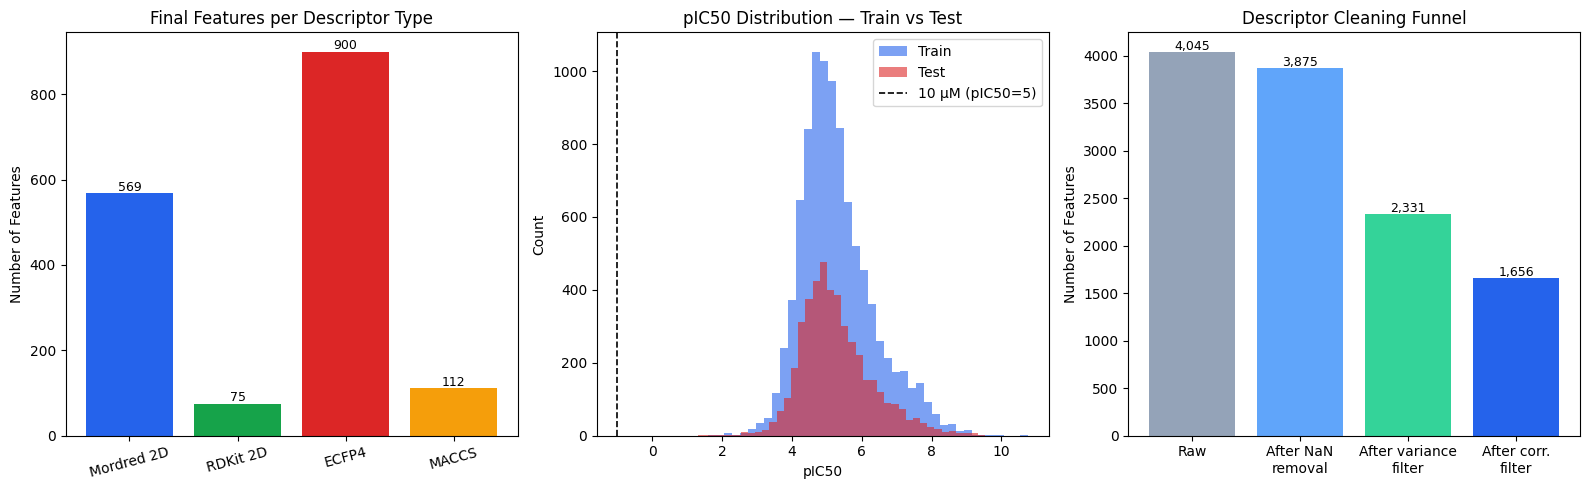

Figure saved: figures/descriptor_overview.png


In [13]:
# ============================================================
# CELL 12: Visualisation — Descriptor Overview
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Feature counts per descriptor type ---
type_counts = {
    'Mordred 2D': sum(1 for c in desc.columns if c.startswith('mordred_')),
    'RDKit 2D'  : sum(1 for c in desc.columns if c.startswith('rdkit_')),
    'ECFP4'     : sum(1 for c in desc.columns if c.startswith('ECFP4_')),
    'MACCS'     : sum(1 for c in desc.columns if c.startswith('MACCS_')),
}
axes[0].bar(type_counts.keys(), type_counts.values(),
            color=['#2563EB', '#16A34A', '#DC2626', '#F59E0B'])
axes[0].set_title('Final Features per Descriptor Type')
axes[0].set_ylabel('Number of Features')
axes[0].tick_params(axis='x', rotation=15)
for i, (k, v) in enumerate(type_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# --- Plot 2: pIC50 distribution train vs test ---
axes[1].hist(y_train['pIC50'], bins=40, alpha=0.6, label='Train', color='#2563EB')
axes[1].hist(y_test['pIC50'],  bins=40, alpha=0.6, label='Test',  color='#DC2626')
axes[1].axvline(x=-np.log10(10), color='black', linestyle='--', linewidth=1.2,
                label='10 µM (pIC50=5)')
axes[1].set_xlabel('pIC50')
axes[1].set_ylabel('Count')
axes[1].set_title('pIC50 Distribution — Train vs Test')
axes[1].legend()

# --- Plot 3: Feature cleaning funnel ---
funnel_labels = ['Raw', 'After NaN\nremoval', 'After variance\nfilter', 'After corr.\nfilter']
funnel_values = [
    all_desc_df.shape[1],
    all_desc_df.shape[1] - len(drop_nan),
    all_desc_df.shape[1] - len(drop_nan) - len(drop_const) - len(drop_low),
    desc.shape[1],
]
axes[2].bar(funnel_labels, funnel_values, color=['#94A3B8', '#60A5FA', '#34D399', '#2563EB'])
axes[2].set_title('Descriptor Cleaning Funnel')
axes[2].set_ylabel('Number of Features')
for i, v in enumerate(funnel_values):
    axes[2].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
figures_dir = PROJECT_ROOT / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'descriptor_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: figures/descriptor_overview.png")


In [15]:
# ============================================================
# CELL 13: QC Checkpoint QC-3
# ============================================================

print("=" * 60)
print("QUALITY CONTROL CHECKPOINT QC-3: Descriptor Calculation")
print("=" * 60)

checks = {}

checks['Descriptor matrix has no NaN']  = not X_train.isna().any().any()
checks['Descriptor matrix has no Inf']  = not np.isinf(X_train.values.astype(float)).any()
checks[f'Features > 100 (actual: {desc.shape[1]})']          = desc.shape[1] > 100
checks[f'Train size > 1,000 (actual: {len(X_train):,})']     = len(X_train) > 1000
checks[f'Test size  > 400  (actual: {len(X_test):,})']       = len(X_test)  > 400

train_active = (y_train['activity_class'] == 'Active').mean()
test_active  = (y_test['activity_class']  == 'Active').mean()
balance_ok   = abs(train_active - test_active) < 0.05
checks[f'Class balance consistent train/test (diff={abs(train_active-test_active):.3f})'] = balance_ok

all_passed = True
for check, passed in checks.items():
    symbol = 'PASS' if passed else 'FAIL'
    print(f"  [{symbol}] {check}")
    if not passed:
        all_passed = False

print("=" * 60)
if all_passed:
    print("ALL CHECKS PASSED — Ready for Notebook 04 (Feature Selection)")
else:
    print("SOME CHECKS FAILED — Review before proceeding")
print("=" * 60)


QUALITY CONTROL CHECKPOINT QC-3: Descriptor Calculation
  [PASS] Descriptor matrix has no NaN
  [PASS] Descriptor matrix has no Inf
  [PASS] Features > 100 (actual: 1656)
  [PASS] Train size > 1,000 (actual: 9,563)
  [PASS] Test size  > 400  (actual: 4,482)
  [PASS] Class balance consistent train/test (diff=0.000)
ALL CHECKS PASSED — Ready for Notebook 04 (Feature Selection)
